# Aperture Photometry

## 1. Load Data

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Telescope**: 7DT16  
- **Filter**: r-band
- **Pattern**: Files ending with `*100.fits`


In [17]:
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.telname = '7DT16'
dbrowser.filter = 'r'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:01<00:00, 69.94it/s]


(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.fits'}>)

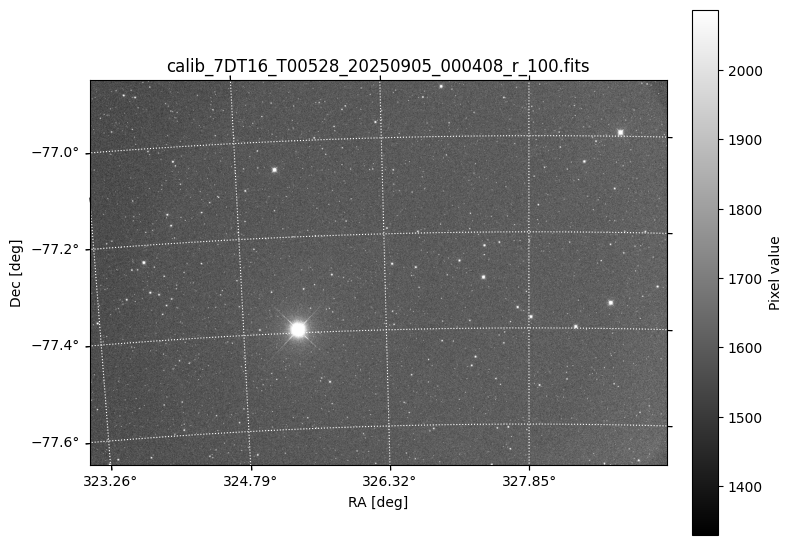

In [18]:
target_img = target_imglist[0]
target_img.show('coord')

## 2. Aperture Photometry 


As you did with source-extractor, you can do photometry easily. 

In [19]:
from ezphot.methods import AperturePhotometry
aperturephot = AperturePhotometry()
aperturephot.help()

Help for AperturePhotometry

Public methods:
- circular_photometry(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], x_arr: Union[float, list, numpy.ndarray], y_arr: Union[float, list, numpy.ndarray], aperture_diameter_arcsec: Union[float, list] = [5, 7, 10], aperture_diameter_seeing: Union[float, list] = [3.5, 4.5], annulus_width_arcsec: Union[float, list] = None, unit: str = 'pixel', target_bkg: Optional[ezphot.imageobjects.background.Background] = None, target_mask: Union[str, pathlib.Path, numpy.ndarray] = None, target_bkgrms: Optional[ezphot.imageobjects.errormap.Errormap] = None, save: bool = True, verbose: bool = True, visualize: bool = True, save_fig: bool = False, **kwargs)
- elliptical_photometry(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], x_arr: Union[float, list, numpy.ndarray], y_arr: Union[float, list, numpy.ndarray], sma_arr: Union[f

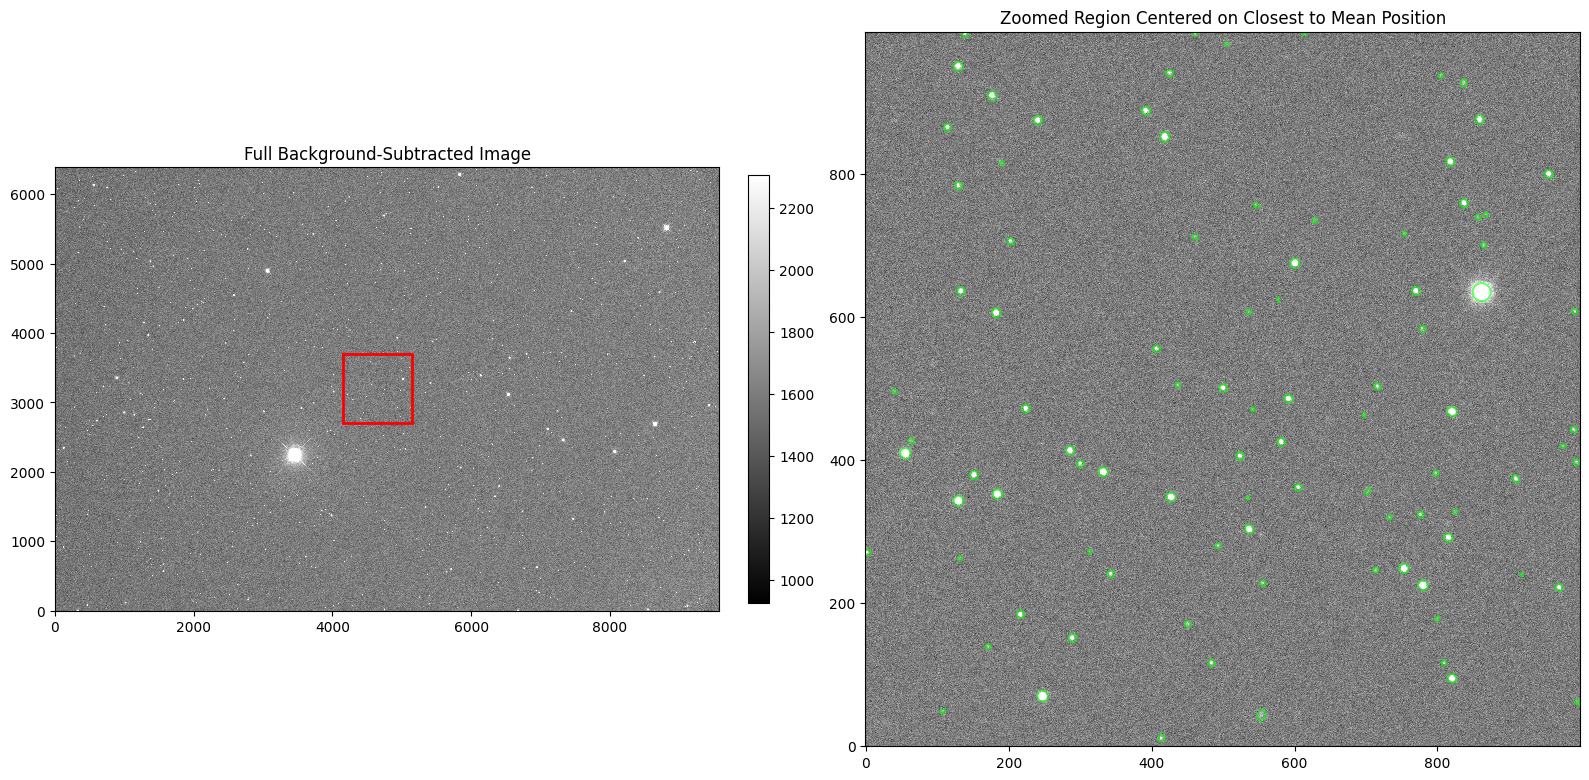

In [20]:
target_catalog = aperturephot.sex_photometry(
    target_img = target_img,
    target_bkg = None,
    target_bkgrms = None,
    target_mask = None,
    sex_params = None,
    detection_sigma = 3,
    aperture_diameter_arcsec = [5, 7, 10],
    aperture_diameter_seeing = [2.5, 3.5],
    saturation_level = 60000,
    kron_factor = 2.5,
    save = False,
    verbose = False,
    visualize = True,
    save_fig = False,
)

The output will be Catalog instance, which has information about the exposure and catalog data. For more detail, See :doc:`api/catalog`

In [21]:
print(target_catalog.info)

Info ============================================
  path: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits.cat
  target_img: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits
  obsdate: 2025-09-05T00:04:08.000
  filter: r
  exptime: 100.0
  depth: 18.917
  seeing: 2.36567556
  catalog_type: all
  ra: 326.2506400247
  dec: -77.26445076037
  fov_ra: 1.35
  fov_dec: 0.9
  objname: T00528
  observatory: 7DT
  telname: 7DT16
  aperture_diameter_arcsec: None


In [22]:
print('exptime: ', target_catalog.info.exptime)
print('filter: ', target_catalog.info.filter)
print('telname: ', target_catalog.info.telname)
print('objname: ', target_catalog.info.objname)
print('ra: ', target_catalog.info.ra)
print('dec: ', target_catalog.info.dec)

exptime:  100.0
filter:  r
telname:  7DT16
objname:  T00528
ra:  326.2506400247
dec:  -77.26445076037


In [23]:
target_catalog.data

NUMBER,FLUX_AUTO,FLUXERR_AUTO,FLUX_APER,FLUX_APER_1,FLUX_APER_2,FLUX_APER_3,FLUX_APER_4,FLUXERR_APER,FLUXERR_APER_1,FLUXERR_APER_2,FLUXERR_APER_3,FLUXERR_APER_4,MAG_AUTO,MAGERR_AUTO,MAG_APER,MAG_APER_1,MAG_APER_2,MAG_APER_3,MAG_APER_4,MAGERR_APER,MAGERR_APER_1,MAGERR_APER_2,MAGERR_APER_3,MAGERR_APER_4,FWHM_IMAGE,FWHM_WORLD,X_IMAGE,Y_IMAGE,XWIN_IMAGE,YWIN_IMAGE,X_WORLD,Y_WORLD,ALPHA_J2000,DELTA_J2000,FLAGS,CLASS_STAR,THRESHOLD,A_IMAGE,B_IMAGE,ELONGATION,ELLIPTICITY,KRON_RADIUS,FLUX_RADIUS,THETA_IMAGE,THETA_WORLD,THETA_SKY,THETA_J2000,BACKGROUND,FLUX_MAX,ISOAREA_IMAGE,SKYSIG,SKYVAL,DETECT_THRESH,NPIX_AUTO,NPIX_APER,PIXSIZE_APER,NPIX_APER_1,PIXSIZE_APER_1,NPIX_APER_2,PIXSIZE_APER_2,NPIX_APER_3,PIXSIZE_APER_3,NPIX_APER_4,PIXSIZE_APER_4
,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,pix,deg,pix,pix,pix,pix,deg,deg,deg,deg,,,ct,pix,pix,,,,pix,deg,deg,deg,deg,ct,ct,pix2,,,,,,,,,,,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str7,str7,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,3475194.0,4071.333,2615010.0,3122994.0,3389156.0,2904196.0,3274413.0,3270.809,3626.474,3897.45,3467.059,3758.364,-16.3524,0.0013,-16.0437,-16.2364,-16.3252,-16.1576,-16.2878,0.0014,0.0013,0.0012,0.0013,0.0012,6.81,0.0009596185,465.3993,85.0813,466.1607,86.0496,323.34446647,-77.669370046,323.3444665,-77.66937,4,0.986,119.6758,3.744,3.282,1.141,0.123,3.5,3.335,72.05,69.59,20.41,20.41,1568.936,74824.11,782,79.7839,1600.87,3,472.8902699336432,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,106.73131589999937,11.657381012281448,209.1933791639988,16.32033341719403
2,4682401.0,4626.969,3681776.0,4236729.0,4549012.0,4003064.0,4406062.0,3855.179,4182.981,4440.203,4038.597,4306.339,-16.6762,0.0011,-16.4151,-16.5676,-16.6448,-16.506,-16.6101,0.0011,0.0011,0.0011,0.0011,0.0011,5.26,0.0007418799,9107.2598,75.1177,9108.3396,76.0409,329.05032598,-77.706008998,329.050326,-77.706009,4,0.999,119.6758,3.607,3.55,1.016,0.016,3.5,3.204,-55.36,-60.84,-29.16,-29.16,1644.865,77106.31,959,79.7839,1600.87,3,492.788377956411,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,106.73131589999937,11.657381012281448,209.1933791639988,16.32033341719403
3,87379.0,1237.503,78710.19,85644.98,91592.54,82538.36,88330.0,892.8154,1137.859,1521.521,1003.417,1300.072,-12.3535,0.0154,-12.2401,-12.3318,-12.4047,-12.2916,-12.3653,0.0123,0.0144,0.018,0.0132,0.016,4.03,0.000567679,8996.917,33.0905,8997.8245,34.1068,328.97806156,-77.712245461,328.9780616,-77.7122455,0,0.983,119.6758,2.04,1.998,1.021,0.021,3.84,2.346,73.99,71.53,18.47,18.47,1644.937,4253.208,93,79.7839,1600.87,3,188.81564337369477,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,106.73131589999937,11.657381012281448,209.1933791639988,16.32033341719403
4,2750105.0,3590.613,2341714.0,2594538.0,2734537.0,2486534.0,2670451.0,3103.453,3329.873,3554.348,3223.346,3430.649,-16.0984,0.0014,-15.9238,-16.0352,-16.0922,-15.989,-16.0665,0.0014,0.0014,0.0014,0.0014,0.0014,4.47,0.0006295678,8536.9443,23.8725,8537.9367,24.845,328.67459563,-77.714705828,328.6745956,-77.7147058,6,0.999,119.6758,3.0,2.908,1.031,0.03,3.5,2.622,-62.91,-64.84,-25.16,-25.16,1644.18,72861.62,591,79.7839,1600.87,3,335.7388652964876,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,106.73131589999937,11.657381012281448,209.1933791639988,16.32033341719403
5,81819.98,1405.131,65568.94,78359.66,83449.36

The output catalog will have column with the prefix (_1, _2, _3...).
Each column with the prefix will corresponsing to each aperutre size. 

Currently, we set
aperture_diameter_arcsec = [5,7,10]
aperture_diameter_seeing = [2.5, 3.5]

Then,
MAG_APER = 5"
MAG_APER_1 = 7"
MAG_APER_2 = 10"
MAG_APER_3 = 2.5 x Seeing
MAG_APER_4 = 3.5 x Seeing

## 3. Aperture Photometry with bkg and bkgrms

If you do not input target_bkg and target_bkgrms, this code calculate the background/RMS map as source-extractor does.
If you want to calculate the background better, you need to manually calculate the background/RMS map for better detection and photometry
 

Added circular mask at (325.37, -77.39) with radius 300arcsec


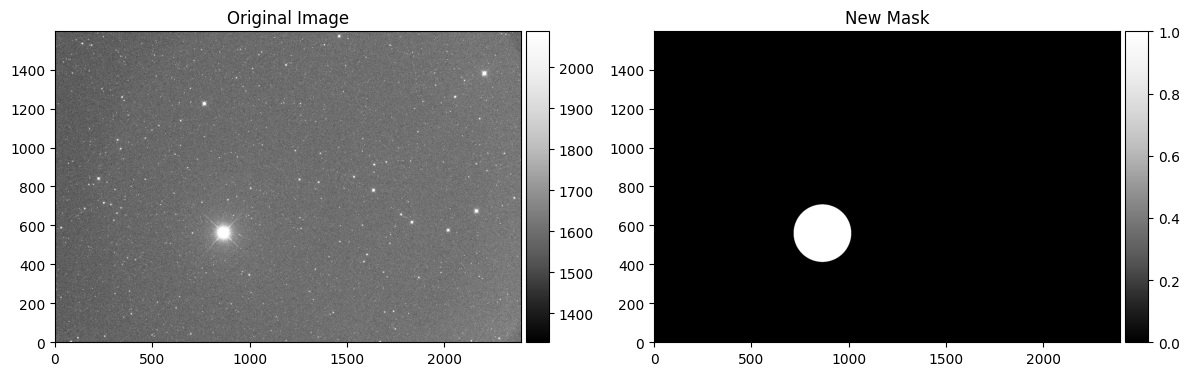

External mask is loaded.
Masking source... [sigma = 5, mask_radius_factor = 2]
5025 non-saturated, 104 saturated sources
5129 sources masked.


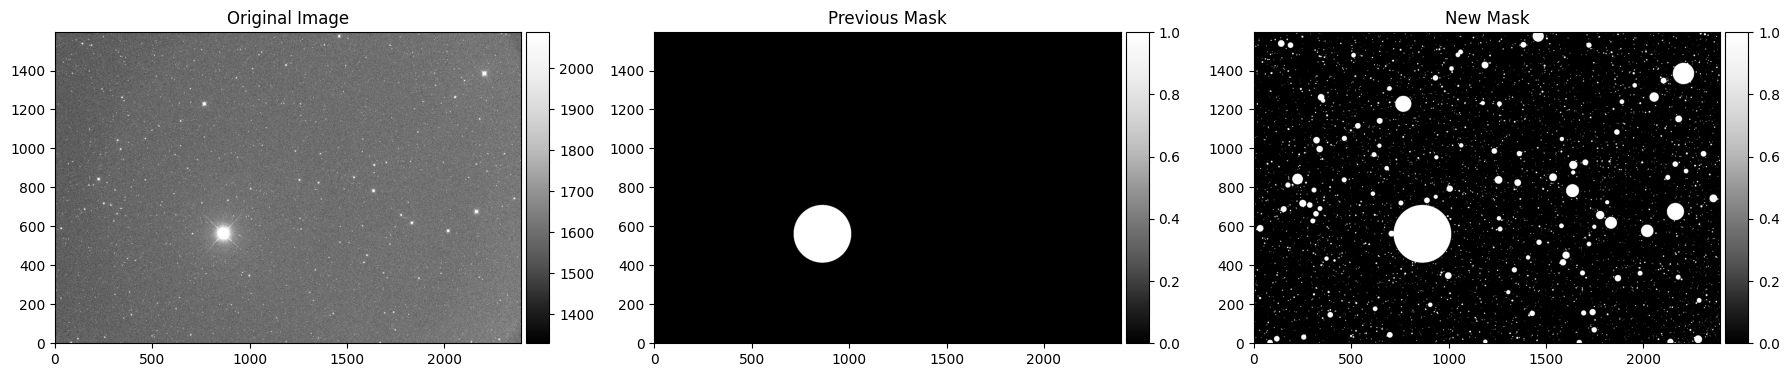

In [26]:
target_brightstar_mask = target_img.calculate_circularmask(
    target_srcmask = None,
    x_position = 325.37,
    y_position = -77.393,
    radius_arcsec = 300,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)
target_srcmask = target_img.calculate_sourcemask(
    target_srcmask = target_brightstar_mask,
    sigma = 5,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)

For calculation of background and background RMS map, see below  

**Background estimation:** :doc:`Background tutorial <example/backgroundestimation>`  

**Background RMS estimation:** :doc:`RMS tutorial <example/backgroundestimation>`

External mask is loaded.


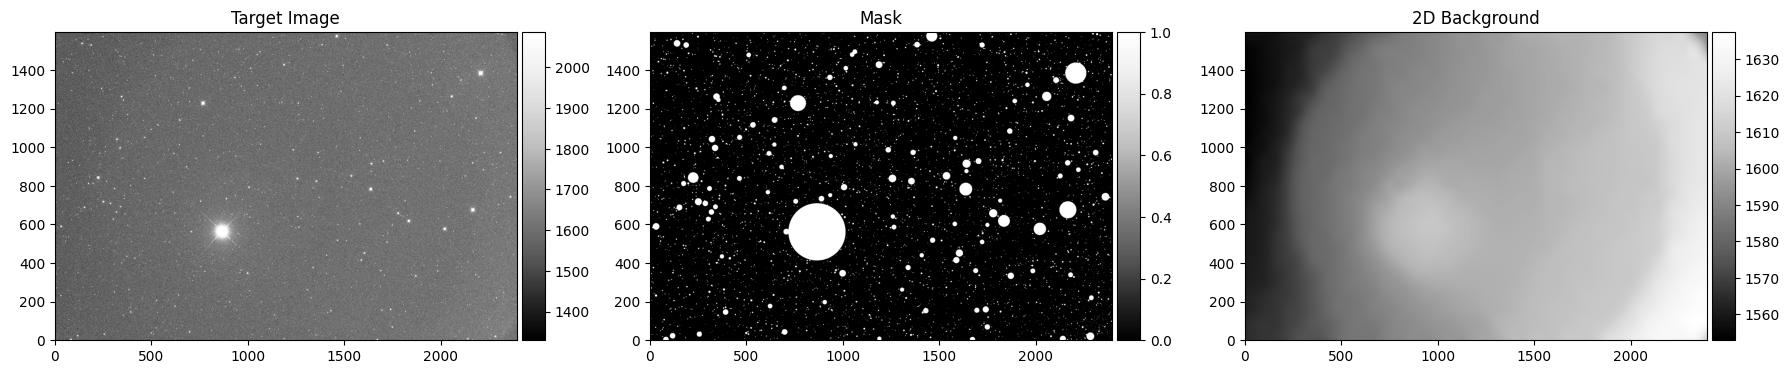

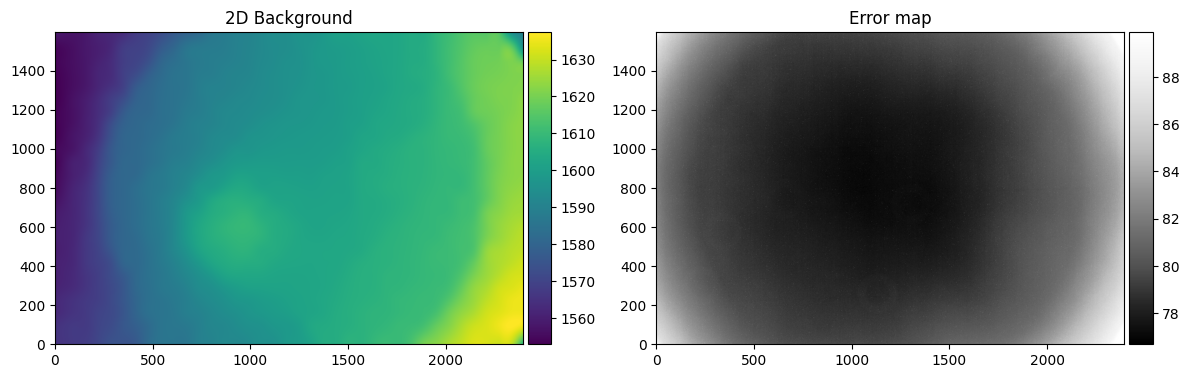

In [33]:
target_bkg = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 256,
    filter_size = 5,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)
target_bkgrms = target_img.calculate_bkgrms_from_propagation(
    target_bkg = target_bkg)


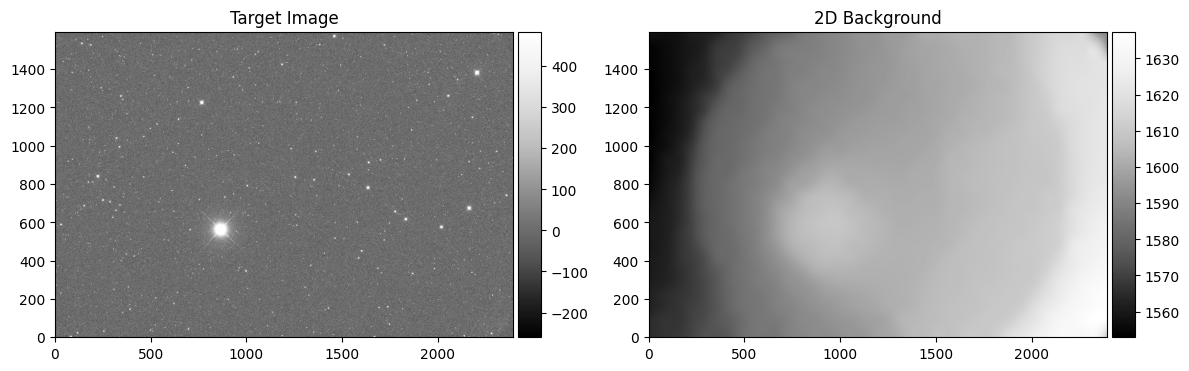

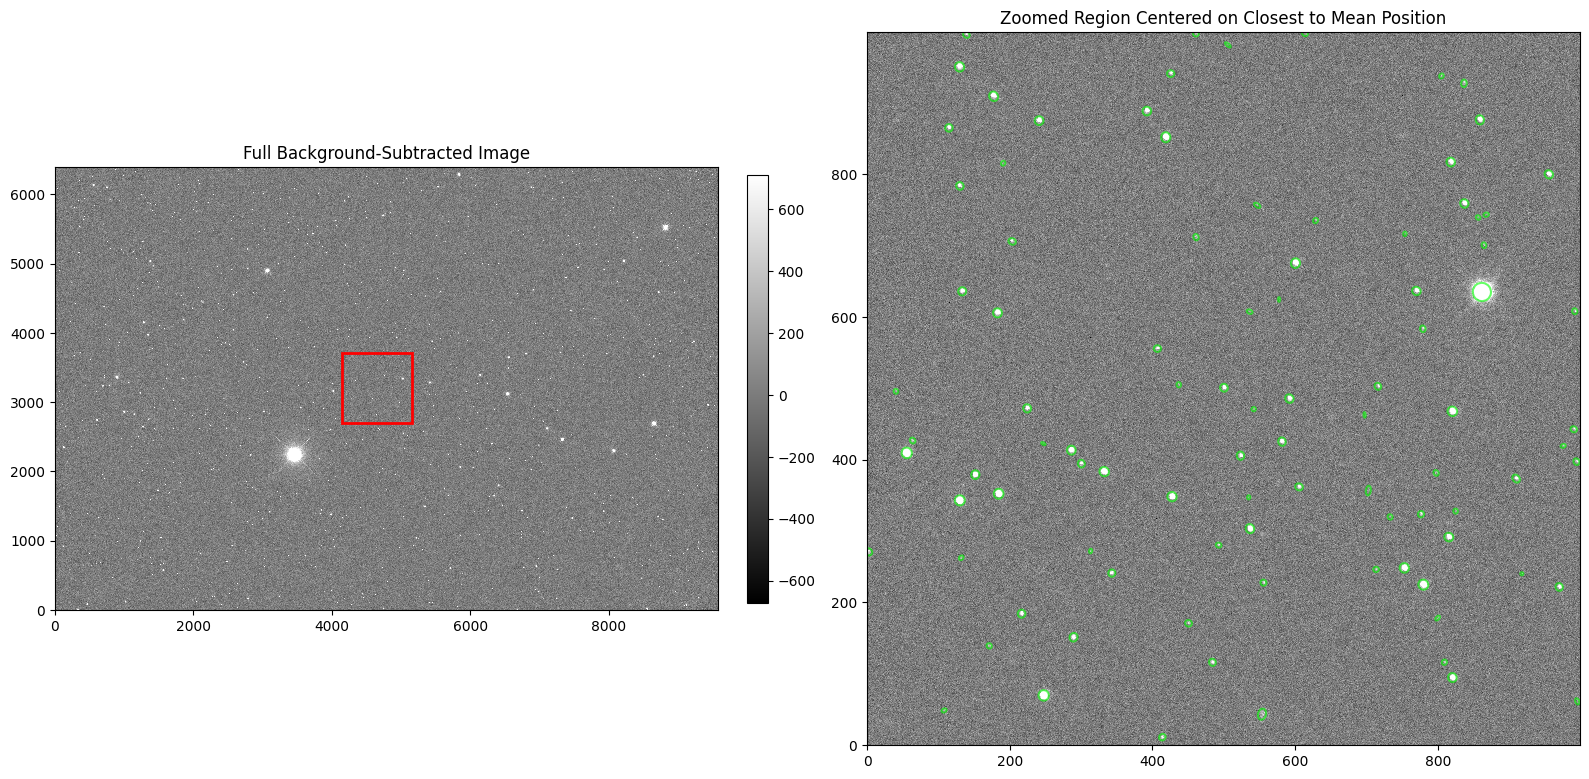

In [34]:
target_catalog = aperturephot.sex_photometry(
    target_img = target_img,
    target_bkg = target_bkg,
    target_bkgrms = target_bkgrms,
    target_mask = None,
    sex_params = None,
    detection_sigma = 3,
    aperture_diameter_arcsec = [5, 7, 10],
    aperture_diameter_seeing = [2.5, 3.5],
    saturation_level = 60000,
    kron_factor = 2.5,
    save = False,
    verbose = False,
    visualize = True,
    save_fig = False,
)